<div style="text-align: center; font-weight: bold; font-size: 150%">Projet 2 - DIverse Counterfactual Explanations (DICE)</div><br>
<div style="text-align: center; font-size: 100%">Yayrale AKIBODE</div><br>
<div style="text-align: center; font-size: 100%">Professeur: Stéphane CHRETIEN</div><br>
<div style="text-align: center; font-size: 100%">M2 MALIA - Université Lumière Lyon 2</div>

Ce travail se base sur le notebook [ici](https://colab.research.google.com/drive/1JojqoTO26iJVM9UTp4H3Be1_f-eDObMH?usp=sharing).

<div style="text-align: center; font-weight: bold; font-size: 125%">1. Méthode DICE</div><br>

L'idée de la méthode DICE est d'expliquer les décisions d'un modèle en générant plusieurs scénarios.

Pour cela on cherche un ensemble de points(counterfactual) $\{c_1, c_2, ..., c_k\}$ tq la décision $f(c_i) \neq f(x)$ où x est une observation du dataset original. Les counterfactuals doivent respecter les points ci-dessous.

- Diversité: $dist(c_i,c_j)$ doit être très grande. Pour modéliser cela on utilise  le Determinantal Point Process:

\begin{gather}
dpp\_diversity  = det(K)
\end{gather}
où $K_{i,j} = \frac{1}{1+dist(c_i,c_j)} $ et $dist(c_i,c_j)$ est une distance.

- Proximité: les counterfactuals doivent rester proches de l'observation originale x. Elle est modélisée par: 

\begin{gather}
Proximité  := -\frac{1}{k} \sum_{i=1}^{k} dist(c_i, x)
\end{gather}

En tenant compte de tous ces points, la méthode DICE revient à résoudre le problème d'optimisation suivant:

\begin{gather}
C(x)  = arg\;min_{c_1, c_2, ..., c_k} \frac{1}{k}\sum_{i=1}^{k} yloss(f(c_i), y) + \frac{\lambda_1}{k} \sum_{i=1}^{k} dist(c_i, x) \\ - \lambda_2 dpp\_diversity(c_1, c_2, ..., c_k)
\end{gather}

où $yloss()$ est une fonction qui mesure la distance entre $f(c_i)$ et $y$. $\lambda_1$ and $\lambda_2$ sont des hyperparamètres.

<div style="text-align: center; font-weight: bold; font-size: 125%">2. Étude de  du notebook original: Bipolar Disease Crisis Prediction</div><br>

Dans un premier temps nous avons manipulé des données sur les troubles bipolaires.

Le trouble bipolaire, anciennement appelé psychose maniaco-dépressive, est une maladie mentale caractérisée par d’importantes variations de l’humeur, alternant entre des phases d’excitation (manie ou hypomanie) et des phases dépressives. Ces épisodes s’accompagnent souvent de manifestations physiques et psychologiques variées.

L’objectif de ce notebook est d'expliquer les causes des troubles bipolaires en analysant plusieurs scénarios avec la méthode DICE.

Les étapes sont les suivantes:

1. Importation des données.
2. Apprentissage d'un modèle RandomForest.
3. Nous appliquons une méthode DICE pour interpréter le modèle.


In [1]:
################## Downdload the git repository ############
! git clone https://github.com/ayoubelqadi/xai-tutorial.git

fatal: destination path 'xai-tutorial' already exists and is not an empty directory.


In [2]:
######### Change  directory for running the data processing scripts
import os
os.chdir('xai-tutorial/notebooks')

In [3]:
%run ../src/setup.py
%run ../src/process_data.py

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

<div style="text-align: center; font-weight: bold; font-size: 100%">2.1. Pipeline d'apprentissage</div><br>

In [4]:
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

#pd.set_option("max_rows", 500)
#pd.set_option("max_columns", 500)

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("font", size=16)

from xgboost import XGBClassifier
from sklearn import metrics
from sklearn import model_selection



In [5]:
#####Importing the data
path_features = "../data/features.csv"
path_target = "../data/target.csv"
features = pd.read_csv(path_features)
target = pd.read_csv(path_target)

In [6]:
#####Transforming the data
def inverse_transform(df):
    df_ = df.copy()
    df_["gender"] = df_["gender"].map({2: "male", 1: "female"})
    df_["work"] = df_["work"].map({2.0: "unemployed/sick/pension", 1.0: "working/studying"})
    df_["marriage"] = df_["marriage"].map({1.0: "married/cohabiting", 2.0: "single"})
    df_["melanch"] = df_["melanch"].map({1.0: "melancholia", 2.0: "no melancholia", 0.0: "no data"})
    df_["inpatient"] = df_["inpatient"].map({1.0: "inpatient", 2.0: "outpatient"})
    return df_

features = inverse_transform(features)

**Target Distribution**


- Bipolar II: **1**

- Unipolar Depressive: **0**

Sur les 22 observations il y a 15 individus qui sont Unipolar Depressive et 7 qui sont Bipolar II. Il y a donc un déséquilibre de classes.

<Axes: ylabel='afftype'>

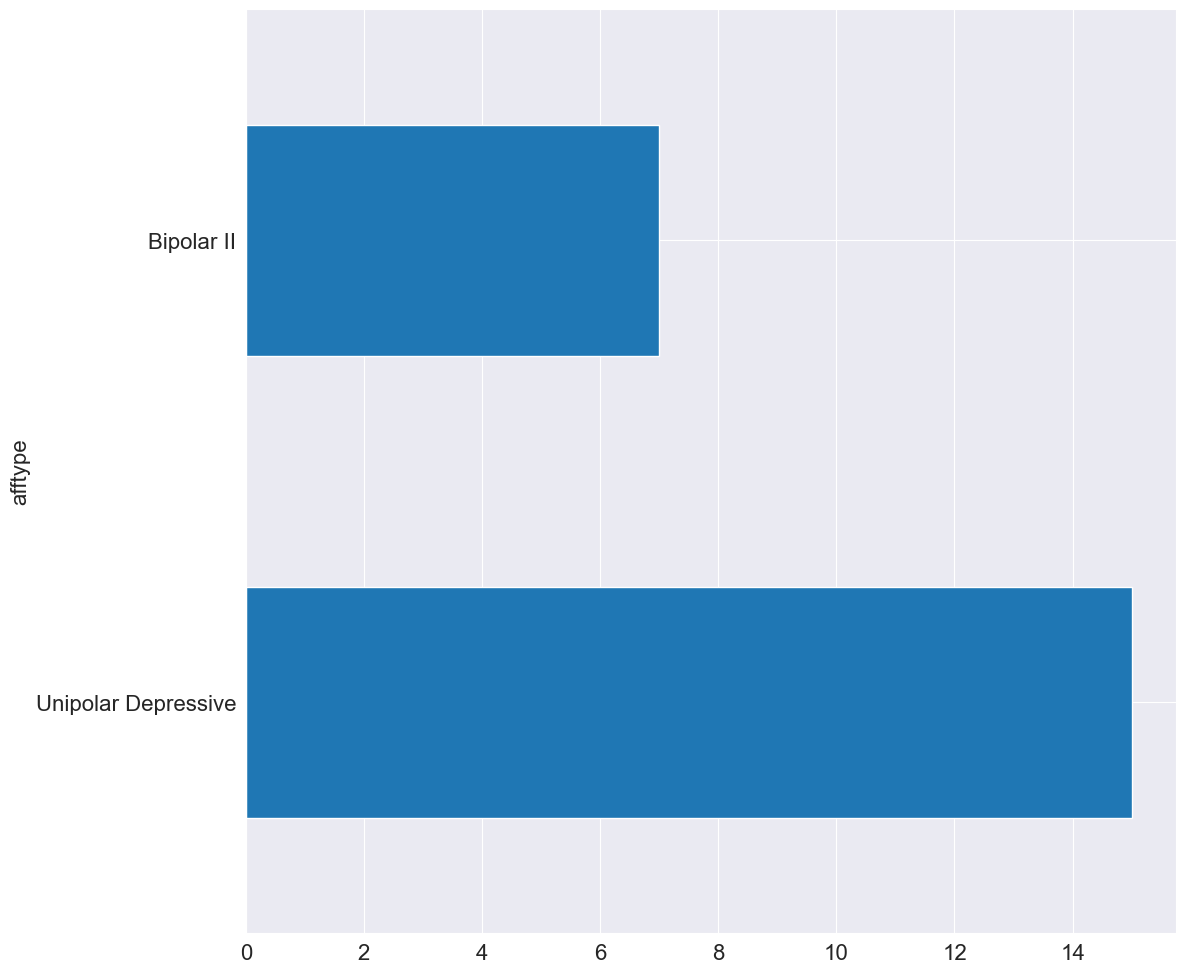

In [7]:
###Exploring the target variable
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12,12))
counter = target["afftype"].value_counts()
counter.rename(index={1.0: "Bipolar II",
                       0.0: "Unipolar Depressive"},
               inplace=True
              )
ax.set_xlabel("# Cases", size=16)
counter.plot(kind="barh", ax=ax)


In [8]:
####Initializing the features and target variables
x, y = features, target

In [9]:
####Splitting the data into train and test sets
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,
                                                                    y,
                                                                    test_size=0.3,
                                                                    random_state=80,
                                                                    stratify=target)

In [10]:
####Displaying train set
x_train

,days,gender,age,melanch,inpatient,edu,marriage,work,madrs1,madrs2,activity_mean,activity_std
7,5,male,25-29,NaN,outpatient,11-15,married/cohabiting,unemployed/sick/pension,20.0,16.0,316.545,503.483
15,16,female,45-49,no melancholia,outpatient,11-15,married/cohabiting,unemployed/sick/pension,13.0,17.0,338.069,424.913
18,13,female,30-34,melancholia,inpatient,6-10,married/cohabiting,unemployed/sick/pension,27.0,25.0,171.471,220.950
8,13,male,45-49,NaN,outpatient,6-10,married/cohabiting,unemployed/sick/pension,26.0,26.0,289.151,348.722
13,14,female,60-64,no melancholia,outpatient,6-10,single,unemployed/sick/pension,28.0,19.0,205.845,262.523
1,18,male,40-44,no melancholia,outpatient,6-10,single,unemployed/sick/pension,24.0,11.0,153.673,330.808
16,13,female,50-54,no melancholia,outpatient,6-10,married/cohabiting,unemployed/sick/pension,17.0,15.0,147.850,211.517
5,7,female,35-39,no melancholia,outpatient,6-10,married/cohabiting,unemployed/sick/pension,18.0,15.0,361.821,382.775
2,13,female,45-49,no melancholia,outpatient,6-10,single,unemployed/sick/pension,24.0,25.0,265.300,399.881
10,14,female,45-49,no melancholia,outpatient,6-10,married/cohabiting,unemployed/sick/pension,24.0,24.0,300.669,369.657


**Entraînement du modèle**

In [11]:
####Importing the necessary libraries for building the model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

In [12]:
####Specifying the categorical and numerical features for building the model
categoric_features = [
    'gender',
    'work',
    'marriage',
    'melanch',
    'inpatient',
    "age",
    "edu"
]
numeric_features = set(features.columns)-set(categoric_features)

In [13]:
####Specifying the categories for each categorical feature
cat_types = []
for cat in categoric_features:
    cat_i = list(features[cat].unique())
    cat_types.append(cat_i)

In [14]:
####Building the preprocessor for the model
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(transformers=[('categorical', categorical_transformer, categoric_features)])


In [15]:
####Building the model
params_rf = {
    "n_estimators": 50,
    "max_depth": 8,
    "random_state":27,
}
rf = RandomForestClassifier(**params_rf)

In [16]:
#Model object: takes original data, processes it and applies the random forest
clf_rf = Pipeline(steps=[
                      ('preprocessor', preprocessor),
                      ('classifier', rf)
])
model = clf_rf.fit(x_train , y_train)

Text(0.5, 1.0, 'Confusion Matrix (Train set)')

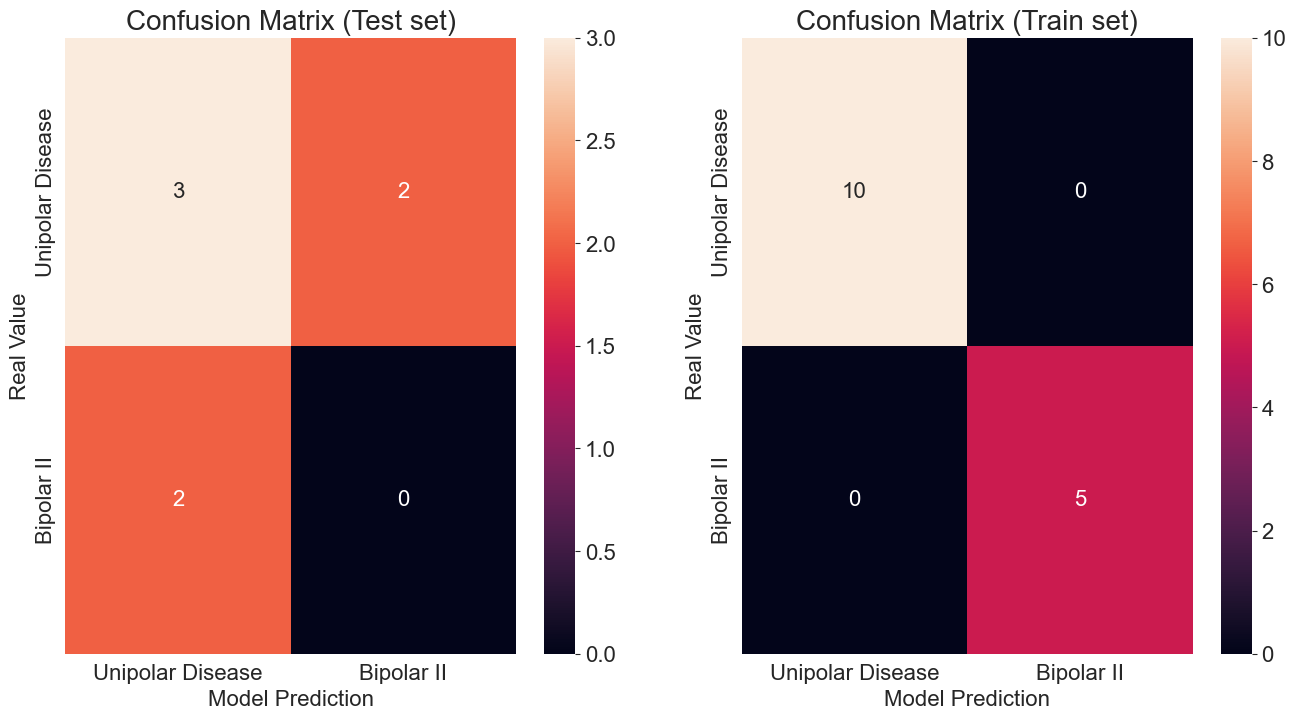

In [17]:
####Evaluating the model
y_hat = clf_rf.predict(x_test)
cf = metrics.confusion_matrix(y_pred=y_hat, y_true=y_test)
cf_train = metrics.confusion_matrix(y_pred=clf_rf.predict(x_train), y_true=y_train)
names_df = [
    "Unipolar Disease",
    "Bipolar II"
]
cf_df = pd.DataFrame(data=cf, columns=names_df, index=names_df)
cf_train_df = pd.DataFrame(data=cf_train, columns=names_df, index=names_df)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

sns.heatmap(cf_df, fmt="d",annot=True, ax=ax[0])
ax[0].set_xlabel("Model Prediction", size=16)
ax[0].set_ylabel("Real Value", size=16)
ax[0].set_title("Confusion Matrix (Test set)", size=20)

sns.heatmap(cf_train_df, fmt="d",annot=True, ax=ax[1])
ax[1].set_xlabel("Model Prediction", size=16)
ax[1].set_ylabel("Real Value", size=16)
ax[1].set_title("Confusion Matrix (Train set)", size=20)

<div style="text-align: center; font-weight: bold; font-size: 100%">2.2. DICE</div><br>

In [18]:
#Loading the dice module
import dice_ml
from dice_ml.utils import helpers
import json

In [19]:
#DiCE data object
X = pd.concat([features, target], axis=1)
#{1.0: "Bipolar II", 0.0: "Unipolar Depressive"}
data = dice_ml.Data(dataframe=X, continuous_features=list(numeric_features), outcome_name='afftype')
#DiCE model object
model_exp = dice_ml.Model(model=model, backend='sklearn')
#Creates the explanations
exp = dice_ml.Dice(data, model_exp, method="random")

Le patient 2 est "Unipolar Depressive" et le modèle l'a prédit "Unipolar Depressive". La méthode DICE va permettre de déterminer sur quelle variable jouer pour que ce patient devienne "Bipolar II".

In [20]:
patient_index = 2

# Patient real target value
diagnosis_map = {1.0: "Bipolar II",
                0.0: "Unipolar Depressive"}
print("-------Patient Real Diagnosis------")

print(y.replace(diagnosis_map).iloc[patient_index])
print("-------Patient Predicted Diagnosis------")
pred_class = clf_rf.predict(X.loc[patient_index:patient_index, :])[0]
if pred_class==0.0:
    pred_diagnosis = diagnosis_map[0.0]
    p1 = clf_rf.predict_proba(X.loc[patient_index:patient_index, :])[0][0]
    p1_round = round(p1,3)
else:
    pred_diagnosis = diagnosis_map[1.0]
    p1 = clf_rf.predict_proba(X.loc[patient_index:patient_index, :])[0][1]
    p1_round = round(p1,3)
print(f'Probability of being diagnosed with a {pred_diagnosis} \n{p1_round}')

-------Patient Real Diagnosis------
afftype    Unipolar Depressive
Name: 2, dtype: object
-------Patient Predicted Diagnosis------
Probability of being diagnosed with a Unipolar Depressive 
0.76


Les variables à faire varier sont: [
    "marriage",
    "work",
    "edu",
    "age",
    "madrs1",
    "madrs2",
]. Le nombre de counterfactual est de 2.

In [21]:
#We take an example of our training set
#We set the number of counterfactual explanations to 2.
#patient_index = 2
features_to_vary = [
    "marriage",
    #"days",
    #"melanch",
    #"inpatient",
    "work",
    "edu",
    "age",
    "madrs1",
    "madrs2",
]
e1 = exp.generate_counterfactuals(features[patient_index:patient_index+1],
                                  total_CFs=2,
                                  desired_class="opposite",
                                 random_seed=3434,
                                 features_to_vary=features_to_vary)
#Show counterfactual explanations
e1.visualize_as_dataframe(show_only_changes=False)

100%|██████████| 1/1 [00:00<00:00, 10.18it/s]

Query instance (original outcome : 0.0)


,days,gender,age,melanch,inpatient,edu,marriage,work,madrs1,madrs2,activity_mean,activity_std,afftype
0,13,female,45-49,no melancholia,outpatient,6-10,single,unemployed/sick/pension,24.0,25.0,265.299988,399.881012,0.0



Diverse Counterfactual set (new outcome: 1.0)


,days,gender,age,melanch,inpatient,edu,marriage,work,madrs1,madrs2,activity_mean,activity_std,afftype
0,13,female,60-64,no melancholia,outpatient,6-10,single,unemployed/sick/pension,24.0,25.0,265.3,399.881,1.0
1,13,female,50-54,no melancholia,outpatient,6-10,single,unemployed/sick/pension,24.0,25.0,265.3,399.881,1.0


On peut également ajouter les probabilités de prédiction, pour voir à quel point la variation de la variable impacte la prédiction.

In [22]:
###Add Proba given by the model for the CF
CF_dice = e1.cf_examples_list[0].final_cfs_df
pred_cf = clf_rf.predict_proba(CF_dice.drop(columns=["afftype"]))
CF_dice[["Unipolar Prob", "Bipolar Prob"]] = pred_cf

CF_dice

,days,gender,age,melanch,inpatient,edu,marriage,work,madrs1,madrs2,activity_mean,activity_std,afftype,Unipolar Prob,Bipolar Prob
0,13,female,60-64,no melancholia,outpatient,6-10,single,unemployed/sick/pension,25.7,25.0,265.3,399.881,1.0,0.16,0.84
1,13,female,50-54,no melancholia,outpatient,6-10,single,unemployed/sick/pension,22.3,25.0,265.3,399.881,1.0,0.30,0.70


Le modèle basé sur DICE n'a fait varié que la variable "age". Enlevons cette dernière de la liste pour voir comment se comporte le modèle.

In [23]:
#We take an example of our training set
#We set the number of counterfactual explanations to 2.
#patient_index = 2
features_to_vary = [
    "marriage",
    #"days",
    #"melanch",
    #"inpatient",
    "work",
    "edu",
    "madrs1",
    "madrs2",
]
try:
    e1 = exp.generate_counterfactuals(features[patient_index:patient_index+1],
                                      total_CFs=2,
                                      desired_class="opposite",
                                     random_seed=3434,
                                     features_to_vary=features_to_vary)
except Exception as e:
    print("An error occurred while generating counterfactual explanations:", str(e))

100%|██████████| 1/1 [00:00<00:00, 18.79it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
An error occurred while generating counterfactual explanations: No counterfactuals found for any of the query points! Kindly check your configuration.


**Conclusion 1:**

La première remarque est que la méthode DICE n'a fait que varier la variable "age" pour générer les counterfactual. Le résultat nous indique que plus une personne est âgée, plus il est plus probable qu'elle soit atteinte de troubles bipolaires. Ensuite lorsque nous avons supprimé la variable "age" des variables à faire varier, le modèle n'a trouvé aucun counterfactual. Cela montre que le modèle est soumis à des contraintes de calcul et d'optimisation. Dans ce cas, est-ce que cette méthode nous a vraiment aidé à expliquer le modèle? Dans ce contexte précis c'est difficile à dire. Pour une étude plus approfondie, nous allons appliquer la même méthode sur un autre jeu de données.

<div style="text-align: center; font-weight: bold; font-size: 125%">3. Étude de cas: La dépression chez les étudiants</div><br>

Nous avons ensuite travaillé avec un jeu de données qui a été construit en réalisant des enquêtes auprès de 100000 étudiants. L'enquête est axée sur leurs habitudes de vie, leurs performances académiques et leur bien-être mental. Chaque ligne représente un étudiant unique avec des détails démographiques, des habitudes de vie, des performances académiques. Le but de cette enquête est d'établir si un étudiant est en dépression ou en bonne santé.

Dans la suite, ce que nous essayerons de faire est d'expliquer les facteurs qui contribuent à la dépression d'un étudiant en générant des counterfactuals d'explication.

Les variables que nous aurons à manipuler sont décrites comme ci-dessous:

- **student_ID** : l'ID d'un étudiant
- **gender** : sexe de l'étudiant (0 = homme, 1 = femme)
- **age** : âge de l'étudiant
- **department** : le domaine d'étude
- **cgpa** : moyenne cumulative des notes
- **sleep_duration** : nombre moyen d'heures de sommeil par nuit
- **study_hours** : nombre moyen d'heures d'étude par jour
- **social_media_hours** : temps moyen passé sur les réseaux sociaux par jour (en heures)
- **physical_activity** : fréquence de l'exercice physique par semaine
- **stress_level** : niveau de stress donné par l'étudiant lui-même
- **depression** : étudiant probablement dépressif ou en bonne santé

**Source**

[Student Depression & Lifestyle (100k Data) sur Kaggle](https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data)


<div style="text-align: center; font-weight: bold; font-size: 100%">3.1. Pipeline d'apprentissage</div><br>

In [24]:
! pip install kagglehub

In [25]:
####Data importation
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")

print("Path to dataset files:", path)

dataset = pd.read_csv(os.path.join(path, "student_lifestyle_100k.csv"))

dataset

Path to dataset files: /Users/yayraleakibode/.cache/kagglehub/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data/versions/1


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False
...,...,...,...,...,...,...,...,...,...,...,...
99995,100996,24,Female,Medical,2.02,7.0,0.6,1.4,66,4,False
99996,100997,24,Male,Arts,2.33,5.0,3.6,5.2,103,3,False
99997,100998,24,Female,Engineering,2.23,6.5,5.8,4.1,61,5,False
99998,100999,19,Male,Engineering,3.61,6.1,4.8,4.9,116,4,False


In [26]:
####Selecting a subset of observations for the model
sub_dataset = dataset.sample(n=100, random_state=80)
sub_dataset=sub_dataset.reset_index(drop=True)

In [27]:
####Data preprocessing
features = sub_dataset.drop(columns=["Depression"])
target = sub_dataset["Depression"]

target_map = {False: 0, True: 1}
target = target.map(target_map)


<Axes: ylabel='Depression'>

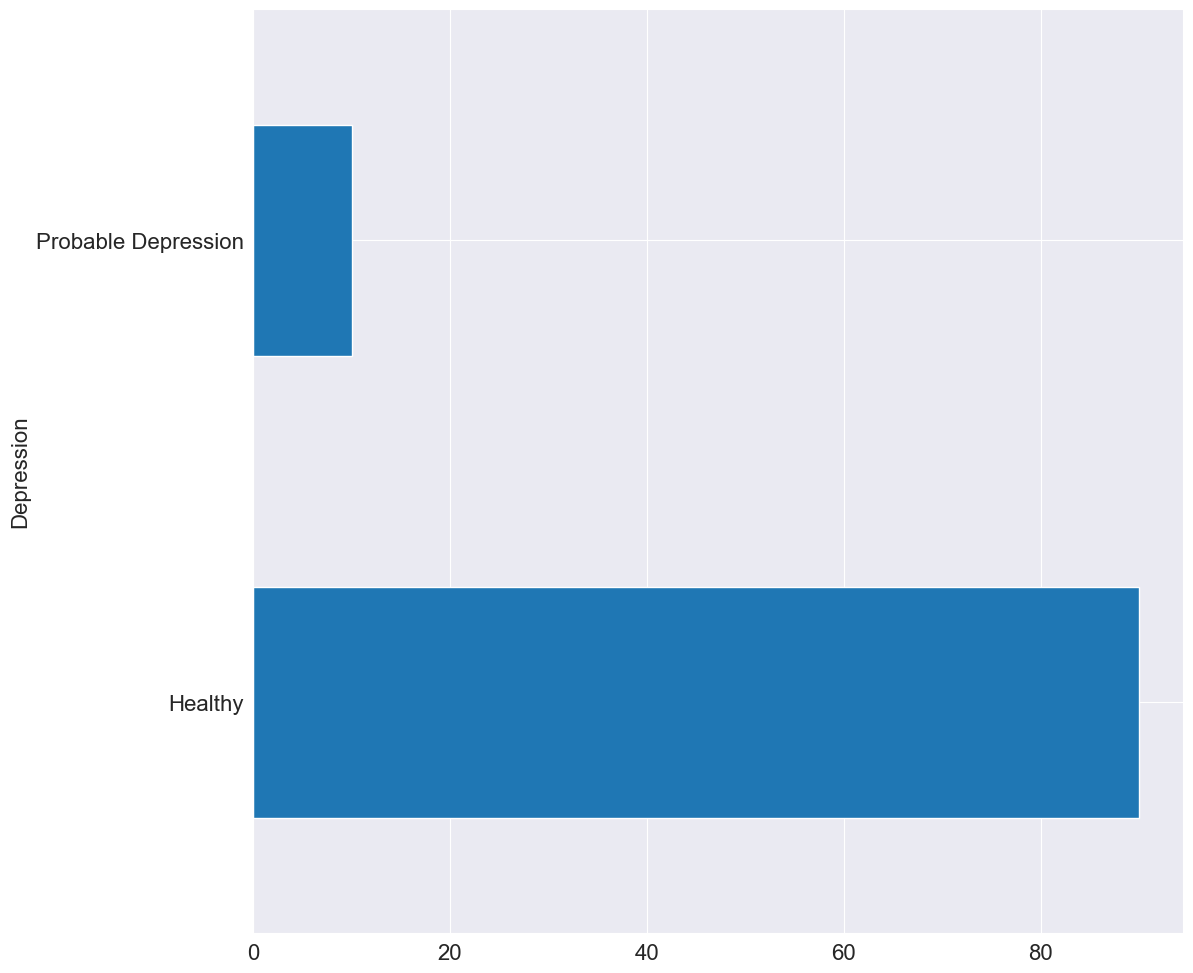

In [28]:
###Exploring the target variable
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12,12))
counter = target.value_counts()
counter.rename(index={1.0: "Probable Depression",
                       0.0: "Healthy"},
               inplace=True
              )
ax.set_xlabel("# Cases", size=16)
counter.plot(kind="barh", ax=ax)

In [29]:
####Splitting the data into train and test sets
x_train, x_test, y_train, y_test = model_selection.train_test_split(features,
                                                                    target,
                                                                    test_size=0.3,
                                                                    random_state=80,
                                                                    stratify=target)

In [30]:
####Specifying the categorical and numerical features for building the model
categoric_features = [
    'Gender',
    'Department',
]
numeric_features = set(features.columns)-set(categoric_features)

In [31]:
####Specifying the categories for each categorical feature
cat_types = []
for cat in categoric_features:
    cat_i = list(features[cat].unique())
    cat_types.append(cat_i)

In [32]:
####Building the preprocessor for the model
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(transformers=[('categorical', categorical_transformer, categoric_features)])


**Remarque :** Les classes étant déséquilibrées, le modèle a dû mal à prédire des étudiants probablement dépressifs. Dans ce cas, la méthode DICE aura dû mal à générer des counterfactuals qui rendent un étudiant en bonne santé dépressif. Pour cela nous avons ajouté au modèle class_weight="balanced_subsample" qui permet d'avoir de meilleures performances.;

In [33]:
####Building the model
params_rf = {
    "n_estimators": 50,
    "max_depth": 8,
    "random_state":27,
}
rf = RandomForestClassifier(**params_rf, class_weight="balanced_subsample")

In [34]:
#Model object: takes original data, processes it and applies the random forest
clf_rf = Pipeline(steps=[
                      ('preprocessor', preprocessor),
                      ('classifier', rf)
])
model = clf_rf.fit(x_train , y_train)

Text(0.5, 1.0, 'Confusion Matrix (Train set)')

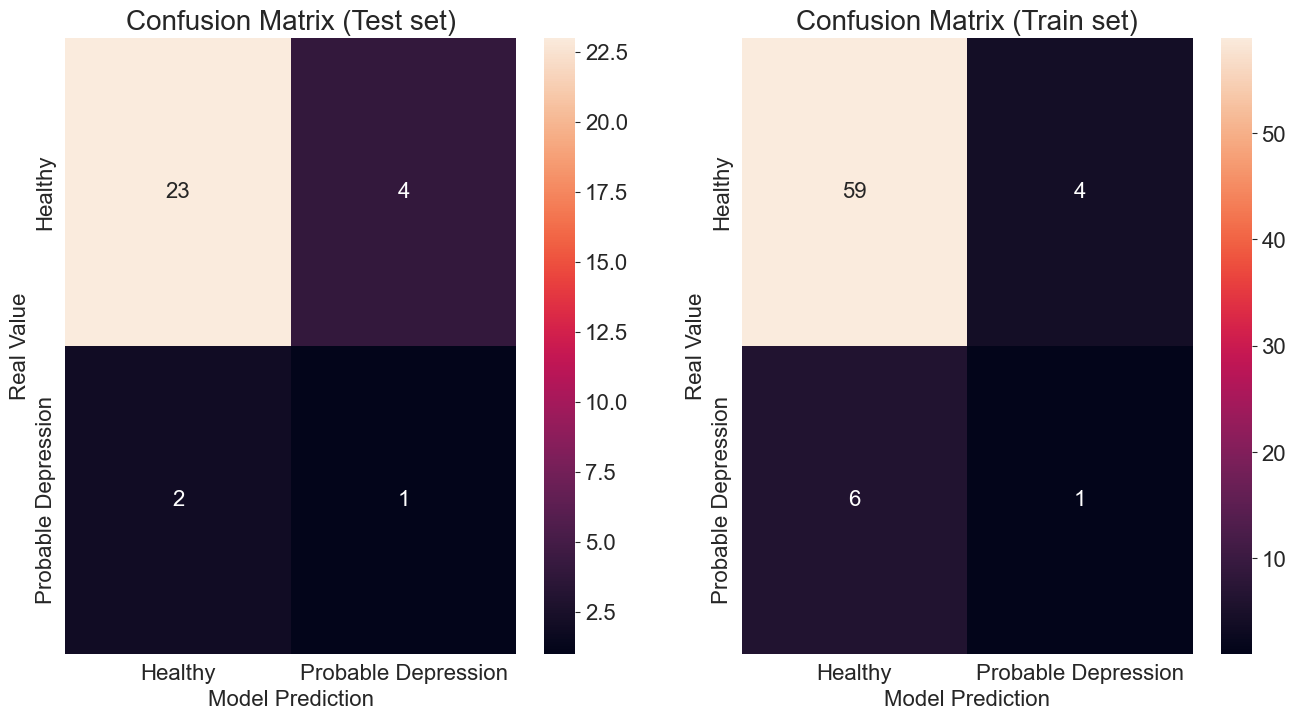

In [35]:
####Evaluating the model
y_hat = clf_rf.predict(x_test)
cf = metrics.confusion_matrix(y_pred=y_hat, y_true=y_test)
cf_train = metrics.confusion_matrix(y_pred=clf_rf.predict(x_train), y_true=y_train)
names_df = [
    "Healthy",
    "Probable Depression"
]
cf_df = pd.DataFrame(data=cf, columns=names_df, index=names_df)
cf_train_df = pd.DataFrame(data=cf_train, columns=names_df, index=names_df)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

sns.heatmap(cf_df, fmt="d",annot=True, ax=ax[0])
ax[0].set_xlabel("Model Prediction", size=16)
ax[0].set_ylabel("Real Value", size=16)
ax[0].set_title("Confusion Matrix (Test set)", size=20)

sns.heatmap(cf_train_df, fmt="d",annot=True, ax=ax[1])
ax[1].set_xlabel("Model Prediction", size=16)
ax[1].set_ylabel("Real Value", size=16)
ax[1].set_title("Confusion Matrix (Train set)", size=20)

<div style="text-align: center; font-weight: bold; font-size: 100%">3.2. DICE</div><br>

In [36]:
#Loading the dice module
import dice_ml
from dice_ml.utils import helpers
import json

In [37]:
#DiCE data object
target = target.rename("depression")
X = pd.concat([features, target], axis=1)
#{1.0: "Bipolar II", 0.0: "Unipolar Depressive"}
data = dice_ml.Data(dataframe=X, continuous_features=list(numeric_features), outcome_name='depression')
#DiCE model object
model_exp = dice_ml.Model(model=model, backend='sklearn')
#Creates the explanations
exp = dice_ml.Dice(data, model_exp, method="random")

Le patient 2 est "Healthy" et le modèle l'a prédit "Healthy" avec une probabilité de 100%. Nous avons utilisé la méthode de DICE pour déterminer sur quelle variable jouer pour que ce patient devienne "Probable Depression".

In [38]:
patient_index = 2

# Patient real target value
diagnosis_map = {1.0: "Probable Depression",
                0.0: "Healthy"}
print("-------Patient Real Diagnosis------")

print(y.replace(diagnosis_map).iloc[patient_index])
print("-------Patient Predicted Diagnosis------")
pred_class = clf_rf.predict(X.loc[patient_index:patient_index, :])[0]
if pred_class==0.0:
    pred_diagnosis = diagnosis_map[0.0]
    p1 = clf_rf.predict_proba(X.loc[patient_index:patient_index, :])[0][0]
    p1_round = round(p1,3)
else:
    pred_diagnosis = diagnosis_map[1.0]
    p1 = clf_rf.predict_proba(X.loc[patient_index:patient_index, :])[0][1]
    p1_round = round(p1,3)
print(f'Probability of being diagnosed with a {pred_diagnosis} \n{p1_round}')

-------Patient Real Diagnosis------
afftype    Healthy
Name: 2, dtype: object
-------Patient Predicted Diagnosis------
Probability of being diagnosed with a Healthy 
1.0


Les variables que nous allons faire varier sont: [
   	"Age", "Gender", "Department",	"CGPA",	"Sleep_Duration",	"Study_Hours",	"Social_Media_Hours",	"Physical_Activity",	"Stress_Level"
]. Le nombre de counterfactual est de 5.

In [39]:
#We take an example of our training set
#We set the number of counterfactual explanations to 5.
#patient_index = 2
features_to_vary = [
   	"Age", "Gender", "Department",	"CGPA",	"Sleep_Duration",	"Study_Hours",	"Social_Media_Hours",	"Physical_Activity",	"Stress_Level"
]
e1 = exp.generate_counterfactuals(features[patient_index:patient_index+1],
                                  total_CFs=5,
                                  desired_class="opposite",
                                 random_seed=3434,
                                 features_to_vary=features_to_vary)
#Show counterfactual explanations
e1.visualize_as_dataframe(show_only_changes=False)

100%|██████████| 1/1 [00:00<00:00, 18.62it/s]

Query instance (original outcome : 0)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,depression
0,28384,23,Female,Arts,2.61,7.1,4.6,3.7,85,2,0



Diverse Counterfactual set (new outcome: 1)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,depression
0,28384,23,Female,Engineering,2.61,7.1,4.6,4.3,85,2,1
1,28384,23,Female,Engineering,2.61,7.1,4.6,3.7,85,2,1
2,28384,23,Female,Engineering,2.61,7.1,4.6,3.7,50,2,1
3,28384,23,Female,Engineering,2.61,6.3,4.6,3.7,85,2,1
4,28384,23,Female,Engineering,2.61,7.1,4.6,3.7,43,2,1


On peut également ajouter les probabilités de prédiction, pour voir à quel point la variation de la variable impacte la prédiction.

In [40]:
###Add Proba given by the model for the CF
CF_dice = e1.cf_examples_list[0].final_cfs_df
pred_cf = clf_rf.predict_proba(CF_dice.drop(columns=["depression"]))
CF_dice[["Healthy Prob", "Depressive Prob"]] = pred_cf

CF_dice

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,depression,Healthy Prob,Depressive Prob
0,28384,23,Female,Engineering,2.61,7.1,4.6,4.3,85,2,1,0.421472,0.578528
1,28384,23,Female,Engineering,2.63,7.1,4.6,3.7,85,2,1,0.421472,0.578528
2,28384,23,Female,Engineering,2.61,7.1,4.6,3.7,50,2,1,0.421472,0.578528
3,28384,23,Female,Engineering,2.61,6.3,4.6,3.7,85,2,1,0.421472,0.578528
4,28384,23,Female,Engineering,2.61,7.1,4.6,3.7,43,2,1,0.421472,0.578528


**Conclusion 2:**

Avec 5 counterfactuals générés, le département de l'étudiant a été changé en Engineering au lieu de Arts. De plus, le modèle a soit augmenté ou soit diminué le nombre d'heures de sommeil par nuit, le temps passé sur les réseaux sociaux et l'activité physique. Le point évident qui ressort est que l'état de l'étudiant dépend énormément du département dans lequel il étudie. Ce qui n'est faux car les études d'ingénierie sont réputés d'être difficiles contrairement aux études de lettres et d'arts. L'activité physique importe également beaucoup dans l'état mental des étudiants.

**Conclusion générale:**

Somme toute, les expérimentations avec ces deux jeux de données ont été très bénéfiques. De fait, la méthode DICE nous permet d'expliquer les prédictions du modèle en faisant varier les valeurs prises par les features. Cela nous permet de déterminer sur quelle feature jouer pour prédire une classe positive. Cependant c'est une méthode qui est soumise à des contraintes d'optimisation, donc peut ne pas donner des résultats dans certains cas. En comparaison à la méthode de SHAP Values, la méthode DICE peut être exploitée comme une méthode complémentaire pour expliquer un modèle sous d'autres angles.